<a href="https://colab.research.google.com/github/AnnaPaulaFigueiredo/data_master/blob/main/05_CLUSTERING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [1]:
from google.colab import drive

import itertools
import shutil
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.figure_factory as ff
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import humanize

from sklearn.impute import SimpleImputer

from pyspark.sql import DataFrame, SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

from pyspark.sql.functions import (
    col,
    concat,
    lit,
    to_date,
)

from pyspark.sql.types import (
    NumericType,
    DateType,
    TimestampType,
    DoubleType,
    FloatType,
    StringType,
)

from pyspark.ml.feature import (
    VectorAssembler,
    StandardScaler,
    PCA,
    StringIndexer,
    OneHotEncoder,
)

from pyspark.ml.functions import vector_to_array

from pyspark.ml.clustering import KMeans

from pyspark.ml.classification import RandomForestClassifier

from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator,
)

from pyspark.ml.tuning import (
    CrossValidator,
    ParamGridBuilder,
)

from pyspark.ml import Pipeline

warnings.filterwarnings("ignore")

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", 500)
pd.set_option("display.float_format", "{:.2f}".format)

IDENTIFY = "msno"

if "spark" not in locals():
    spark = (
        SparkSession.builder
        .appName("DM_CASE")
        .getOrCreate()
    )

print("Spark:", spark.version)

spark.range(1).count()

print("SparkContext funcionando!")
print("Imports realizados com sucesso!")

Spark: 4.0.4
SparkContext funcionando!
Imports realizados com sucesso!


# Load Data

In [2]:
path_dummies = "/content/drive/MyDrive/SANTANDER"

dfs_train_dummy = spark.read.parquet(
    f"{path_dummies}/train_encoded.parquet"
)

dfs_test_dummy = spark.read.parquet(
    f"{path_dummies}/test_encoded.parquet"
)

dfs_validacao_dummy = spark.read.parquet(
    f"{path_dummies}/validation_encoded.parquet"
)

print("\n=== Detalhes dos Conjuntos de Dados ===")

def print_dataset_stats(df, name):
    total_records = df.count()
    churn_count = df.filter(F.col("churn_m3") == 1).count()
    churn_proportion = (churn_count / total_records) * 100 if total_records > 0 else 0
    print(f"\n{name}:")
    print(f"  Total de registros: {total_records:,}")
    print(f"  Proporção de Churn: {churn_proportion:.2f}%")

print_dataset_stats(dfs_train_dummy, "Treino")
print_dataset_stats(dfs_test_dummy, "Teste")
print_dataset_stats(dfs_validacao_dummy, "Validação")


=== Detalhes dos Conjuntos de Dados ===

Treino:
  Total de registros: 962,073
  Proporção de Churn: 14.29%

Teste:
  Total de registros: 959,754
  Proporção de Churn: 12.55%

Validação:
  Total de registros: 976,722
  Proporção de Churn: 12.98%


# Features

In [3]:
def selecionar_features_cluster(
    df,
    features,
    nome_cluster
):
    """
    Seleciona as features utilizadas em um clustering.

    Parâmetros
    ----------
    df : Spark DataFrame
        DataFrame de origem.

    features : list
        Lista explícita das features que participarão do clustering.

    nome_cluster : str
        Nome usado apenas para identificar a análise.

    Retorno
    -------
    df_cluster : Spark DataFrame
        DataFrame contendo apenas as features selecionadas.

    features_validas : list
        Lista das features efetivamente encontradas.
    """

    colunas_disponiveis = set(df.columns)

    features_validas = [
        feature
        for feature in features
        if feature in colunas_disponiveis
    ]

    features_faltantes = [
        feature
        for feature in features
        if feature not in colunas_disponiveis
    ]

    print(f"\n{'=' * 60}")
    print(f"CLUSTER: {nome_cluster}")
    print(f"{'=' * 60}")

    print(f"\nFeatures selecionadas ({len(features_validas)}):")
    for feature in features_validas:
        print(f"  ✓ {feature}")

    if features_faltantes:
        print(f"\nFeatures NÃO encontradas ({len(features_faltantes)}):")
        for feature in features_faltantes:
            print(f"  ✗ {feature}")

    df_cluster = df.select(features_validas)

    return df_cluster, features_validas

De para:
| Métrica                | O que representa          |
| ---------------------- | ------------------------- |
| `total_plays`          | volume de utilização      |
| `total_secs`           | intensidade de consumo    |
| `taxa_completude`      | qualidade do consumo      |
| `skip_ratio`           | comportamento de abandono |
| `diversidade_ratio`    | variedade de conteúdo     |
| `taxa_auto_renew_hist` | histórico de renovação    |


In [4]:
features_cluster_comportamento = [
    "ativo_log",
    "total_plays",
    "total_secs",
    "taxa_completude",
    "skip_ratio",
    "avg_secs_per_play",
    "diversidade_ratio",
    "var_total_plays",
    "var_total_secs",
    "taxa_auto_renew_hist"
]

features_cluster_financeiro = [
    "qtd_transacoes",
    "delta_receita",
    "var_receita",
    "mudanca_preco",
    "intervalo_transacoes_meses",
    "taxa_auto_renew_hist"
]

features_profiling = [
    "churn_m3",
    "bd",
    "gender_unknown",
    "gender_female",
    "gender_male",
    "registered_via_7",
    "registered_via_3",
    "registered_via_9",
    "registered_via_4",

    "perfil_engajamento_engajamento_medio",
    "perfil_engajamento_baixo_engajamento",
    "perfil_engajamento_alto_engajamento",

    "perfil_consumo_rare",
    "perfil_consumo_casual_sporadic",
    "perfil_consumo_heavy_sporadic",
    "perfil_consumo_sem_atividade",

    "perfil_volume_medio",
    "perfil_volume_muito_alto",
    "perfil_volume_alto",
    "perfil_volume_baixo",

    "perfil_frequencia_raro",
    "perfil_frequencia_sem_atividade",

    "tempo_escuta_categoria_curta",
    "tempo_escuta_categoria_media",
    "tempo_escuta_categoria_longa"
]

In [5]:
df_cluster_comportamento, cols_comportamento = (
    selecionar_features_cluster(
        df=dfs_train_dummy,
        features=features_cluster_comportamento,
        nome_cluster="Comportamento"
    )
)


CLUSTER: Comportamento

Features selecionadas (10):
  ✓ ativo_log
  ✓ total_plays
  ✓ total_secs
  ✓ taxa_completude
  ✓ skip_ratio
  ✓ avg_secs_per_play
  ✓ diversidade_ratio
  ✓ var_total_plays
  ✓ var_total_secs
  ✓ taxa_auto_renew_hist


In [6]:
df_cluster_financeiro, cols_financeiro = (
    selecionar_features_cluster(
        df=dfs_train_dummy,
        features=features_cluster_financeiro,
        nome_cluster="Financeiro"
    )
)


CLUSTER: Financeiro

Features selecionadas (6):
  ✓ qtd_transacoes
  ✓ delta_receita
  ✓ var_receita
  ✓ mudanca_preco
  ✓ intervalo_transacoes_meses
  ✓ taxa_auto_renew_hist


# Clustering

## Functions Pipeline

### Pre Processing

In [7]:
def preparar_features_pca(
    df,
    features,
    id_cols=("msno", "safra")
):
    """
    Seleciona as features e cria o vetor de entrada.

    Parâmetros
    ----------
    df : DataFrame
        Dataset de entrada.

    features : list
        Lista das features utilizadas.

    id_cols : tuple
        Colunas identificadoras que serão preservadas.

    Retorno
    -------
    df_assembled : DataFrame
    assembler : VectorAssembler
    """

    df_pca = df.select(
        *id_cols,
        *features
    )

    assembler = VectorAssembler(
        inputCols=features,
        outputCol="features_raw"
    )

    df_assembled = assembler.transform(df_pca)

    return df_assembled, assembler

def padronizar_features(
    df,
    withStd=True,
    withMean=True
):
    """
    Padroniza as features utilizando StandardScaler.

    Retorna o DataFrame transformado e o modelo
    de scaler treinado.
    """

    scaler = StandardScaler(
        inputCol="features_raw",
        outputCol="features_scaled",
        withStd=withStd,
        withMean=withMean
    )

    scaler_model = scaler.fit(df)

    df_scaled = scaler_model.transform(df)

    return df_scaled, scaler_model

def aplicar_pca(
    df,
    pca_k=2
):
    """
    Aplica PCA ao vetor padronizado.

    Retorna:
    - DataFrame com pca_features
    - modelo PCA
    """

    pca = PCA(
        k=pca_k,
        inputCol="features_scaled",
        outputCol="pca_features"
    )

    pca_model = pca.fit(df)

    df_pca = pca_model.transform(df)

    return df_pca, pca_model

def criar_componentes_pca(
    df,
    n_components=2
):
    """
    Converte pca_features em colunas PC1, PC2, ...

    Para n_components=2:
        PC1
        PC2
    """

    df_result = df.withColumn(
        "pca_array",
        vector_to_array("pca_features")
    )

    for i in range(n_components):

        df_result = df_result.withColumn(
            f"PC{i + 1}",
            F.col("pca_array")[i]
        )

    return df_result

def preparar_kmeans(df):
    """
    Prepara o DataFrame para o K-Means.
    """
    return df.select(
        "msno",
        "safra",
        "pca_features"
    )

def avaliar_kmeans_elbow(
    df,
    k_values=range(2, 11),
    features_col="pca_features",
    seed=42
):
    """
    Calcula o WCSS (trainingCost) para diferentes valores de K.

    Retorna:
    - lista de K
    - lista de WCSS
    """

    costs = []

    for k in k_values:

        kmeans = KMeans(
            k=k,
            seed=seed,
            featuresCol=features_col,
            predictionCol="prediction"
        )

        model = kmeans.fit(df)

        cost = model.summary.trainingCost

        costs.append(cost)

        print(
            f"K = {k} | WCSS = {cost}"
        )

    return list(k_values), costs

def plotar_elbow(
    k_values,
    costs
):
    """
    Plota o gráfico do método do cotovelo.
    """

    plt.figure(figsize=(10, 6))

    plt.plot(
        k_values,
        costs,
        marker="o"
    )

    plt.xlabel("Número de clusters (K)")
    plt.ylabel("WCSS / Training Cost")
    plt.title("Método do Cotovelo - K-Means")

    plt.xticks(k_values)
    plt.grid(True)

    plt.show()

### Algoritimo

In [8]:
def treinar_kmeans(df, k):

    kmeans = KMeans(
        k=k,
        seed=42,
        featuresCol="pca_features",
        predictionCol="cluster"
    )

    model = kmeans.fit(df)

    df_clustered = model.transform(df)

    return df_clustered, model
def adicionar_pc1_pc2(
    df
):
    """
    Adiciona PC1 e PC2 a partir de pca_features.
    """

    return (
        df
        .withColumn(
            "pca_array",
            vector_to_array("pca_features")
        )
        .withColumn(
            "PC1",
            F.col("pca_array")[0]
        )
        .withColumn(
            "PC2",
            F.col("pca_array")[1]
        )
    )

### Plots

In [9]:
def plotar_clusters(
    df,
    sample_fraction=None
):
    """
    Plota os clusters usando PC1 e PC2.

    sample_fraction:
        Se informado, utiliza uma amostra para reduzir
        o volume convertido para Pandas.
    """

    df_plot = df.select(
        "PC1",
        "PC2",
        "cluster"
    )

    if sample_fraction is not None:

        df_plot = df_plot.sample(
            withReplacement=False,
            fraction=sample_fraction,
            seed=42
        )

    pdf = df_plot.toPandas()

    plt.figure(figsize=(10, 7))

    for cluster in sorted(pdf["cluster"].unique()):

        dados = pdf[
            pdf["cluster"] == cluster
        ]

        plt.scatter(
            dados["PC1"],
            dados["PC2"],
            label=f"Cluster {cluster}",
            alpha=0.5
        )

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("Clusters dos clientes após PCA")

    plt.legend(title="Cluster")
    plt.grid(True)

    plt.show()

def adicionar_churn(
    df_clustered,
    df_original
):
    """
    Adiciona churn_m3 ao dataset clusterizado.
    """

    churn = df_original.select(
        "msno",
        "safra",
        "churn_m3"
    )

    return (
        df_clustered
        .join(
            churn,
            on=["msno", "safra"],
            how="left"
        )
    )

def churn_por_cluster(
    df
):
    """
    Calcula quantidade de clientes, quantidade de churn
    e taxa de churn por cluster.
    """

    return (
        df
        .groupBy("cluster")
        .agg(
            F.count("*").alias("qtd_clientes"),

            F.sum(
                F.when(
                    F.col("churn_m3") == 1,
                    1
                ).otherwise(0)
            ).alias("qtd_churn"),

            F.avg("churn_m3").alias(
                "taxa_churn"
            )
        )
        .withColumn(
            "taxa_churn_pct",
            F.round(
                F.col("taxa_churn") * 100,
                2
            )
        )
        .orderBy("cluster")
    )

def plotar_churn_por_cluster(
    df,
    sample_fraction=None
):
    """
    Plota somente clientes com churn_m3 = 1.
    """

    # Explicitly select churn_m3, PC1, PC2, cluster to ensure their presence for subsequent operations
    df_temp_plot = df.select(
        "PC1",
        "PC2",
        "cluster",
        "churn_m3"
    )

    df_plot = (
        df_temp_plot
        .filter(F.col("churn_m3") == 1)
    )

    if sample_fraction is not None:

        df_plot = df_plot.sample(
            withReplacement=False,
            fraction=sample_fraction,
            seed=42
        )

    pdf = df_plot.toPandas()

    plt.figure(figsize=(10, 7))

    for cluster in sorted(pdf["cluster"].unique()):

        dados = pdf[
            pdf["cluster"] == cluster
        ]

        plt.scatter(
            dados["PC1"],
            dados["PC2"],
            label=f"Cluster {cluster}",
            alpha=0.5
        )

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(
        "Distribuição dos clientes com churn por cluster"
    )

    plt.legend(title="Cluster")
    plt.grid(True)

    plt.show()

def plotar_centroides(
    df_centroides
):
    """
    Plota os centróides dos clusters em um espaço 2D PCA.
    """

    pdf_centroides = df_centroides.toPandas()

    plt.figure(figsize=(12, 8))

    plt.scatter(
        pdf_centroides["PC1"],
        pdf_centroides["PC2"],
        s=150
    )

    for _, row in pdf_centroides.iterrows():
        plt.annotate(
            f"C{int(row['cluster'])}",
            (row["PC1"],
            row["PC2"]),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=10
        )

    plt.axhline(0, linewidth=0.8)
    plt.axvline(0, linewidth=0.8)

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("Centróides dos clusters comportamentais — PCA 2D")

    plt.tight_layout()
    plt.show()

### Profiling

In [22]:
def gerar_perfil_clusters(
    df_clustered,
    df_original,
    features_comportamento,
    feature_financeira="ticket_medio"
):
    """
    Gera o perfil dos clusters combinando:
    - comportamento
    - churn
    - métrica financeira
    """

    df_base = (
        df_clustered
        .select("msno", "safra", "cluster")
        .join(
            df_original.select(
                "msno",
                "safra",
                "churn_m3",
                *features_comportamento,
                feature_financeira
            ),
            on=["msno", "safra"],
            how="left"
        )
    )

    agregacoes = [
        F.count("*").alias("clientes"),
        F.sum("churn_m3").alias("churns"),
        F.avg("churn_m3").alias("churn_rate"),
        F.avg(feature_financeira).alias("ticket_medio")
    ]

    # Comportamento
    for feature in features_comportamento:
        agregacoes.append(
            F.avg(feature).alias(feature)
        )

    # Financeiro
    agregacoes.extend([
        F.sum(feature_financeira).alias("valor_total"),
        F.sum(
            F.when(
                F.col("churn_m3") == 1,
                F.col(feature_financeira)
            ).otherwise(0)
        ).alias("valor_em_risco")
    ])

    perfil = (
        df_base
        .groupBy("cluster")
        .agg(*agregacoes)
        .orderBy("cluster")
    )

    return perfil

### Churn

In [11]:
def gerar_churn_por_cluster(
    df_clustered,
    df_original
):

    df = (
        df_clustered
        .select("msno", "safra", "cluster")
        .join(
            df_original.select(
                "msno",
                "safra",
                "churn_m3"
            ),
            on=["msno", "safra"],
            how="left"
        )
    )

    resultado = (
        df
        .groupBy("cluster")
        .agg(
            F.count("*").alias("clientes"),
            F.sum("churn_m3").alias("churns"),
            F.avg("churn_m3").alias("churn_rate")
        )
        .orderBy("cluster")
    )

    return resultado

### Oportunidades

In [12]:
def plotar_oportunidades(perfil_churn):

    pdf = perfil_churn.toPandas()

    pdf["pct_clientes"] = (
        pdf["clientes"] / pdf["clientes"].sum() * 100
    )

    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 6))

    plt.scatter(
        pdf["pct_clientes"],
        pdf["churn_rate"] * 100,
        s=120
    )

    for _, row in pdf.iterrows():
        plt.annotate(
            f"C{int(row['cluster'])}",
            (
                row["pct_clientes"],
                row["churn_rate"] * 100
            ),
            xytext=(5, 5),
            textcoords="offset points"
        )

    plt.xlabel("% da base")
    plt.ylabel("Churn (%)")
    plt.title("Clusters comportamentais: tamanho × churn")

    plt.tight_layout()
    plt.show()

### Teste e Validation

In [13]:
def comparar_churn_clusters(
    churn_train,
    churn_test,
    churn_valid
):

    train = churn_train.select(
        "cluster",
        F.col("clientes").alias("clientes_train"),
        F.col("churns").alias("churns_train"),
        F.col("churn_rate").alias("churn_train")
    )

    test = churn_test.select(
        "cluster",
        F.col("clientes").alias("clientes_test"),
        F.col("churns").alias("churns_test"),
        F.col("churn_rate").alias("churn_test")
    )

    valid = churn_valid.select(
        "cluster",
        F.col("clientes").alias("clientes_valid"),
        F.col("churns").alias("churns_valid"),
        F.col("churn_rate").alias("churn_valid")
    )

    comparacao = (
        train
        .join(test, "cluster", "outer")
        .join(valid, "cluster", "outer")
        .orderBy("cluster")
    )

    return comparacao

# Comportamento

In [14]:
df_assembled, assembler = preparar_features_pca(
    dfs_train_dummy,
    cols_comportamento
)

df_scaled, scaler_model = padronizar_features(
    df_assembled
)

df_pca_result, pca_model = aplicar_pca(
    df_scaled,
    pca_k=2
)

df_pca_result = criar_componentes_pca(
    df_pca_result,
    n_components=2
)

df_pca_result.select(
    "msno",
    "safra",
    "PC1",
    "PC2"
).show(2, truncate=False)

+--------------------------------------------+------+------------------+------------------+
|msno                                        |safra |PC1               |PC2               |
+--------------------------------------------+------+------------------+------------------+
|++JGYktWmyC4C/EUf+Q8aLOWtzX063tsvgqJUIyLTkE=|201605|0.3671327773118892|1.36476482669596  |
|++WzwUilDTwylIR3EtdSaXH3iWnmVuWNyq3iiIgCSsM=|201607|0.5341701645954159|1.2179418222453422|
+--------------------------------------------+------+------------------+------------------+
only showing top 2 rows


In [15]:
df_kmeans = df_pca_result.select(
    "msno",
    "safra",
    "pca_features"
)

df_kmeans.show(5, truncate=False)

+--------------------------------------------+------+-----------------------------------------+
|msno                                        |safra |pca_features                             |
+--------------------------------------------+------+-----------------------------------------+
|++JGYktWmyC4C/EUf+Q8aLOWtzX063tsvgqJUIyLTkE=|201605|[0.3671327773118892,1.36476482669596]    |
|++WzwUilDTwylIR3EtdSaXH3iWnmVuWNyq3iiIgCSsM=|201607|[0.5341701645954159,1.2179418222453422]  |
|++Xqq1LcF5dltTfVk8kDh7+DZp1dyzMBuU4tNtCT1p8=|201601|[-1.3102741995840657,0.25470967051914933]|
|++gzbSoJZRJod/mZc38IMuXdshlDpaIS8TU7kiTFXIk=|201607|[0.6900075901303029,2.3836553328485524]  |
|++oXIXmgqlMjdoyLncPieObbuXZeSHGDsI6xk15WkIM=|201602|[1.1288672162698756,1.7803574960943764]  |
+--------------------------------------------+------+-----------------------------------------+
only showing top 5 rows


In [16]:
df_kmeans = preparar_kmeans(
    df_pca_result
)

In [17]:
%%time
k_values, costs = avaliar_kmeans_elbow(
    df_kmeans,
    k_values=range(3, 11),
    seed=42
)

K = 3 | WCSS = 1295026.4292401476
K = 4 | WCSS = 865950.3520886366
K = 5 | WCSS = 682118.4695908567
K = 6 | WCSS = 581141.1388837071
K = 7 | WCSS = 515305.63764691877
K = 8 | WCSS = 308096.6475759658
K = 9 | WCSS = 272880.0181536082
K = 10 | WCSS = 239388.1560603773
CPU times: user 160 ms, sys: 30.4 ms, total: 191 ms
Wall time: 3min 15s


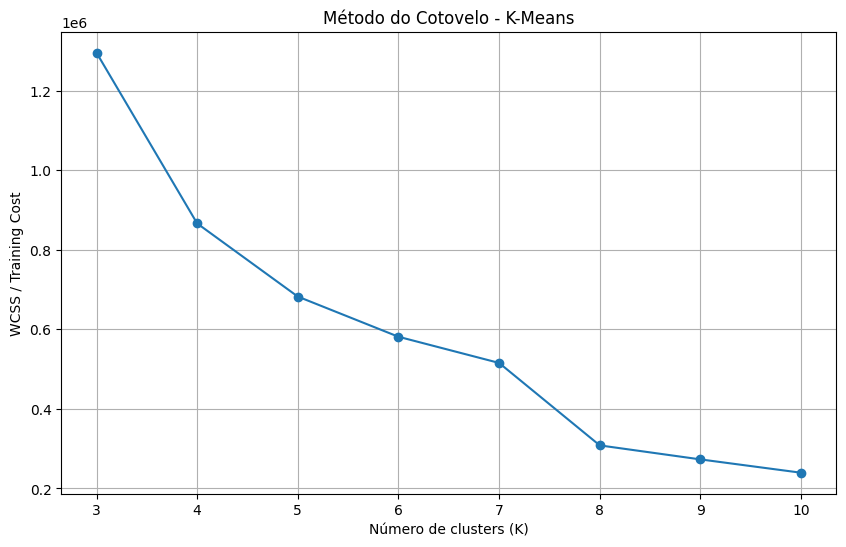

In [18]:
plotar_elbow(
    k_values,
    costs
)

### Best Kmeans

In [19]:
best_k = 8

df_clustered_comportamento, kmeans_model = treinar_kmeans(
    df_kmeans,
    k=best_k
)

In [20]:
df_clustered_comportamento = adicionar_pc1_pc2(
    df_clustered_comportamento
)

df_clustered_comportamento.select(
    "msno",
    "safra",
    "PC1",
    "PC2",
    "cluster"
)

DataFrame[msno: string, safra: string, PC1: double, PC2: double, cluster: int]

### Profiling

In [28]:
perfil_clusters = gerar_perfil_clusters(
    df_clustered_comportamento,
    dfs_train_dummy,
    features_cluster_comportamento+["actual_amount_paid"],
    feature_financeira="actual_amount_paid"
)

pdf_perfil = perfil_clusters.toPandas()
pdf_perfil

,cluster,clientes,churns,churn_rate,ticket_medio,ativo_log,total_plays,total_secs,taxa_completude,skip_ratio,avg_secs_per_play,diversidade_ratio,var_total_plays,var_total_secs,taxa_auto_renew_hist,actual_amount_paid,valor_total,valor_em_risco
0,0,331141,45895,0.14,117.26,1.00,453.34,84420.72,0.76,0.18,203.76,0.82,1.78,9.99,0.88,117.26,38829223.00,3499875.00
1,1,97895,16737,0.17,105.61,0.00,0.07,0.05,0.00,0.00,0.00,0.00,0.00,-0.00,0.99,105.61,10339046.00,1016536.00
2,2,62621,8267,0.13,119.06,1.00,2217.09,484453.84,0.87,0.10,223.87,0.68,4.94,83.11,0.83,119.06,7455868.00,665731.00
3,3,63560,10578,0.17,112.48,1.00,155.20,14416.60,0.23,0.66,96.67,0.86,2.23,7.11,0.92,112.48,7149247.00,736899.00
4,4,15520,2057,0.13,112.97,1.00,4612.50,1037890.57,0.93,0.05,232.36,0.63,5.71,29.43,0.88,112.97,1753353.00,135099.00
5,5,204500,29952,0.15,115.93,1.00,327.09,47249.96,0.54,0.36,160.81,0.82,1.97,7.85,0.89,115.93,23708678.00,2293055.00
6,6,186835,24032,0.13,117.32,1.00,1023.84,209514.11,0.82,0.14,214.52,0.71,2.64,17.80,0.85,117.32,21919629.00,1846734.00
7,7,1,1,1.00,0.00,1.00,1548.00,82541329.07,0.84,0.13,53321.27,0.80,0.88,1.21,1.00,0.00,0.00,0.00


### Churn by Cluster

In [29]:
perfil_churn = gerar_churn_por_cluster(
    df_clustered_comportamento,
    dfs_train_dummy
)

perfil_churn.show()

+-------+--------+------+-------------------+
|cluster|clientes|churns|         churn_rate|
+-------+--------+------+-------------------+
|      0|  331141| 45895|0.13859654950610162|
|      1|   97895| 16737|0.17096889524490524|
|      2|   62621|  8267|0.13201641621820157|
|      3|   63560| 10578|0.16642542479546885|
|      4|   15520|  2057|0.13253865979381443|
|      5|  204500| 29952| 0.1464645476772616|
|      6|  186835| 24032| 0.1286268632750823|
|      7|       1|     1|                1.0|
+-------+--------+------+-------------------+



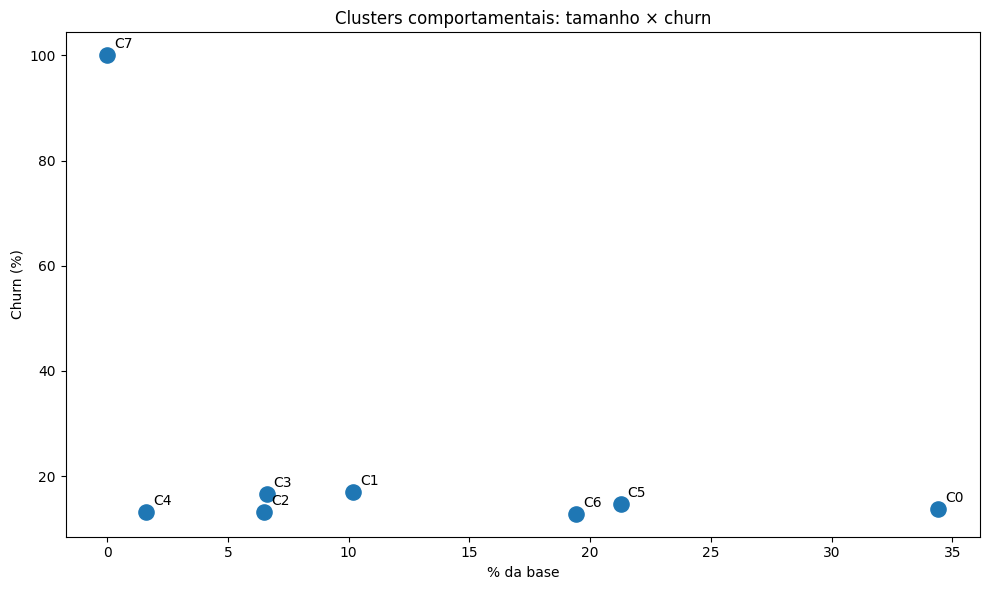

In [30]:
plotar_oportunidades(perfil_churn)

### Plots

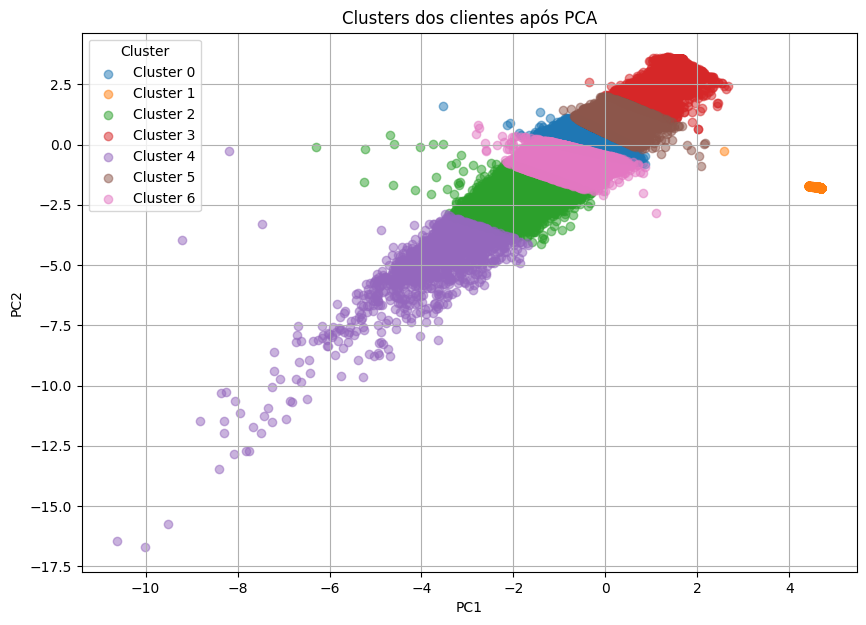

In [31]:
df_visualizacao = (
    df_pca_result
    .select(
        "msno",
        "safra",
        "PC1",
        "PC2"
    )
    .join(
        df_clustered_comportamento.select(
            "msno",
            "safra",
            "cluster"
        ),
        ["msno", "safra"],
        "inner"
    )
)

plotar_clusters(
    df_visualizacao,
    sample_fraction=0.1
)

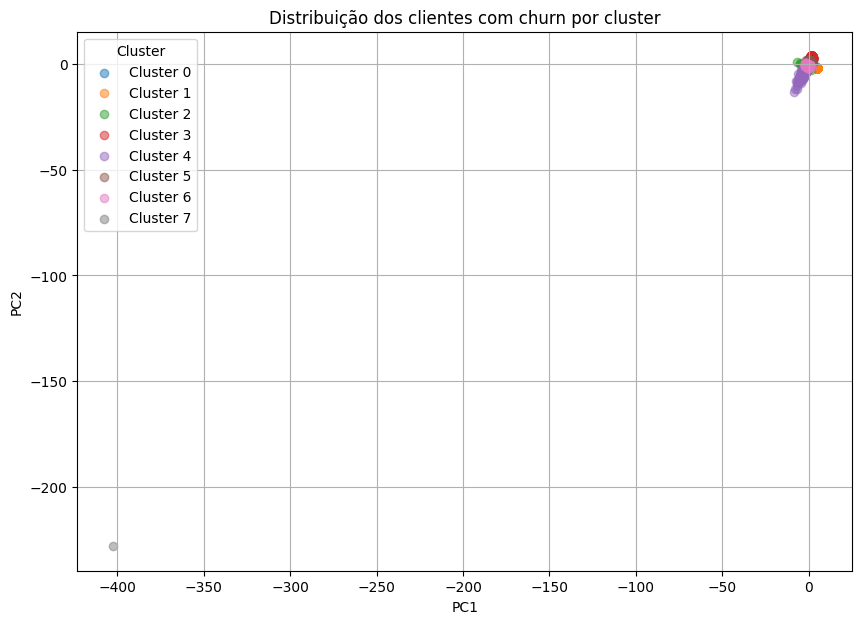

In [32]:
df_clustered_churn = adicionar_churn(
    df_clustered_comportamento,
    dfs_train_dummy
)

plotar_churn_por_cluster(
    df_clustered_churn,
    sample_fraction=0.2
)

In [33]:
df_plot_clusters = df_clustered_churn.select("PC1", "PC2", "cluster")

df_centroides = (
    df_plot_clusters
    .groupBy("cluster")
    .agg(
        F.avg("PC1").alias("PC1"),
        F.avg("PC2").alias("PC2"),
        F.count("*").alias("clientes")
    )
    .orderBy("cluster")
)

df_centroides.show()

+-------+-------------------+-------------------+--------+
|cluster|                PC1|                PC2|clientes|
+-------+-------------------+-------------------+--------+
|      0|-0.5572809718061575| 0.3483825065964602|  331141|
|      1| 4.6960312786502705| -1.790771756982062|   97895|
|      2|-1.9012545102260296|-1.9624364570668853|   62621|
|      3|  0.948078117955367| 2.2110604583457447|   63560|
|      4|-3.6750140775708267| -4.757597878858409|   15520|
|      5| 0.1010836037906364| 1.0616540211838572|  204500|
|      6|-0.9613483245957862|-0.5392123586224933|  186835|
|      7| -402.6544968105821|-227.98705074076324|       1|
+-------+-------------------+-------------------+--------+



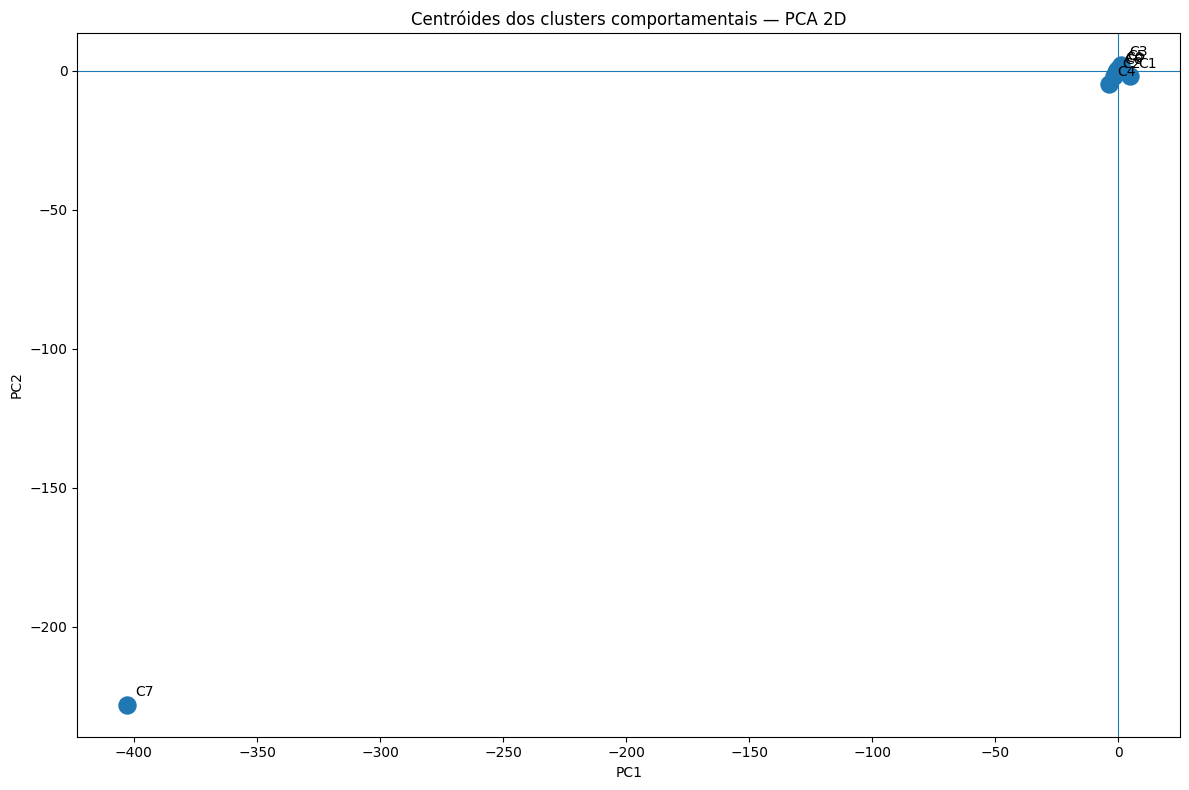

In [34]:
pdf_centroides = df_centroides.toPandas()

plt.figure(figsize=(12, 8))

plt.scatter(
    pdf_centroides["PC1"],
    pdf_centroides["PC2"],
    s=150
)

for _, row in pdf_centroides.iterrows():
    plt.annotate(
        f"C{int(row['cluster'])}",
        (row["PC1"], row["PC2"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=10
    )

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Centróides dos clusters comportamentais — PCA 2D")

plt.tight_layout()
plt.show()

### Matriz

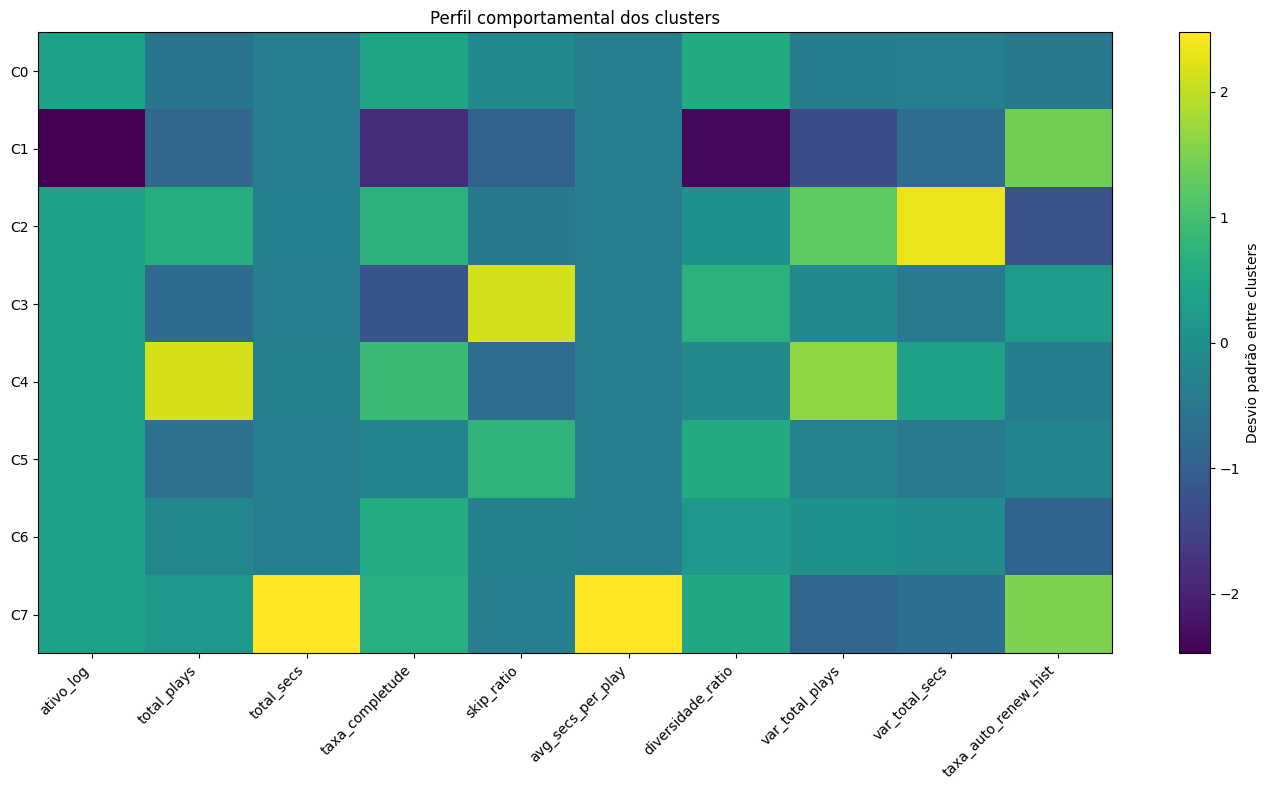

In [35]:
features_plot = [
    "ativo_log",
    "total_plays",
    "total_secs",
    "taxa_completude",
    "skip_ratio",
    "avg_secs_per_play",
    "diversidade_ratio",
    "var_total_plays",
    "var_total_secs",
    "taxa_auto_renew_hist"
]

matriz = (
    pdf_perfil
    .set_index("cluster")[features_plot]
)

# Padronização por feature entre os clusters
matriz_z = (
    matriz - matriz.mean()
) / matriz.std()

plt.figure(figsize=(14, 8))

plt.imshow(
    matriz_z,
    aspect="auto"
)

plt.xticks(
    range(len(features_plot)),
    features_plot,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(matriz_z.index)),
    [f"C{i}" for i in matriz_z.index]
)

plt.colorbar(label="Desvio padrão entre clusters")

plt.title("Perfil comportamental dos clusters")

plt.tight_layout()
plt.show()

## Dados de Teste

In [37]:
# ==========================================
# TEST — CLUSTERIZAÇÃO COM MODELOS DO TRAIN
# ==========================================

# 1. Preparar features
df_test_assembled = assembler.transform(
    dfs_test_dummy
)

# 2. Aplicar scaler treinado no TRAIN
df_test_scaled = scaler_model.transform(
    df_test_assembled
)

# 3. Aplicar PCA treinado no TRAIN
df_test_pca = pca_model.transform(
    df_test_scaled
)

# 4. Criar PC1 e PC2 para visualização
df_test_pca = criar_componentes_pca(
    df_test_pca,
    n_components=2
)

# 5. Preparar entrada do KMeans
df_test_kmeans = preparar_kmeans(
    df_test_pca
)

# 6. Aplicar KMeans treinado no TRAIN
df_test_clustered = kmeans_model.transform(
    df_test_kmeans
)

# ==========================================
# PERFIL COMPORTAMENTAL
# ==========================================

perfil_comportamento_test = gerar_perfil_clusters(
    df_test_clustered,
    dfs_test_dummy,
    features_cluster_comportamento+["actual_amount_paid"],
    feature_financeira="actual_amount_paid"
)

perfil_comportamento_test.show(
    truncate=False
)

# ==========================================
# CHURN POR CLUSTER
# ==========================================

churn_comportamento_test = gerar_churn_por_cluster(
    df_test_clustered,
    dfs_test_dummy
)

churn_comportamento_test.show(
    truncate=False
)

+-------+--------+------+-------------------+------------------+---------------------+---------------------+------------------+--------------------+--------------------+--------------------+---------------------+----------------------+----------------------+--------------------+------------------+-----------+--------------+
|cluster|clientes|churns|churn_rate         |ticket_medio      |ativo_log            |total_plays          |total_secs        |taxa_completude     |skip_ratio          |avg_secs_per_play   |diversidade_ratio    |var_total_plays       |var_total_secs        |taxa_auto_renew_hist|actual_amount_paid|valor_total|valor_em_risco|
+-------+--------+------+-------------------+------------------+---------------------+---------------------+------------------+--------------------+--------------------+--------------------+---------------------+----------------------+----------------------+--------------------+------------------+-----------+--------------+
|0      |324020  |3687

## Validation

In [40]:
# ==========================================
# TEST — CLUSTERIZAÇÃO COM MODELOS DO TRAIN
# ==========================================

# 1. Preparar features
df_validation_assembled = assembler.transform(
    dfs_validacao_dummy
)

# 2. Aplicar scaler treinado no TRAIN
df_validation_scaled = scaler_model.transform(
    df_validation_assembled
)

# 3. Aplicar PCA treinado no TRAIN
df_validation_pca = pca_model.transform(
    df_validation_scaled
)

# 4. Criar PC1 e PC2 para visualização
df_validation_pca = criar_componentes_pca(
    df_validation_pca,
    n_components=2
)

# 5. Preparar entrada do KMeans
df_validation_kmeans = preparar_kmeans(
    df_validation_pca
)

# 6. Aplicar KMeans treinado no TRAIN
df_validation_clustered_comportamento = kmeans_model.transform(
    df_validation_kmeans
)

# ==========================================
# PERFIL COMPORTAMENTAL
# ==========================================

perfil_comportamento_validation = gerar_perfil_clusters(
    df_validation_clustered_comportamento,
    dfs_validacao_dummy,
    features_cluster_comportamento+["actual_amount_paid"],
    feature_financeira="actual_amount_paid"
)

perfil_comportamento_validation.show(
    truncate=False
)

# ==========================================
# CHURN POR CLUSTER
# ==========================================

churn_comportamento_validation = gerar_churn_por_cluster(
    df_validation_clustered_comportamento,
   dfs_validacao_dummy
)

churn_comportamento_validation.show(
    truncate=False
)

+-------+--------+------+-------------------+------------------+--------------------+---------------------+-------------------+-------------------+--------------------+--------------------+--------------------+---------------------+--------------------+--------------------+------------------+-----------+--------------+
|cluster|clientes|churns|churn_rate         |ticket_medio      |ativo_log           |total_plays          |total_secs         |taxa_completude    |skip_ratio          |avg_secs_per_play   |diversidade_ratio   |var_total_plays      |var_total_secs      |taxa_auto_renew_hist|actual_amount_paid|valor_total|valor_em_risco|
+-------+--------+------+-------------------+------------------+--------------------+---------------------+-------------------+-------------------+--------------------+--------------------+--------------------+---------------------+--------------------+--------------------+------------------+-----------+--------------+
|0      |336176  |38455 |0.1143894864

In [41]:
comparacao_comportamento = comparar_churn_clusters(
    perfil_churn,
    churn_comportamento_test,
    churn_comportamento_validation
)

comparacao_comportamento.show(
    truncate=False
)

+-------+--------------+------------+-------------------+-------------+-----------+-------------------+--------------+------------+-------------------+
|cluster|clientes_train|churns_train|churn_train        |clientes_test|churns_test|churn_test         |clientes_valid|churns_valid|churn_valid        |
+-------+--------------+------------+-------------------+-------------+-----------+-------------------+--------------+------------+-------------------+
|0      |331141        |45895       |0.13859654950610162|324020       |36871      |0.1137923584963891 |336176        |38455       |0.11438948645947361|
|1      |97895         |16737       |0.17096889524490524|108511       |17781      |0.16386357143515404|114169        |22404       |0.19623540540777268|
|2      |62621         |8267        |0.13201641621820157|62072        |8742       |0.14083644799587575|56395         |5528        |0.09802287436829506|
|3      |63560         |10578       |0.16642542479546885|67144        |11410      |0.169

# Financeiro

In [42]:
df_assembled, assembler = preparar_features_pca(
    dfs_train_dummy,
    cols_financeiro
)

df_scaled, scaler_model = padronizar_features(
    df_assembled
)

df_pca_result, pca_model = aplicar_pca(
    df_scaled,
    pca_k=2
)

df_pca_result = criar_componentes_pca(
    df_pca_result,
    n_components=2
)

df_pca_result.select(
    "msno",
    "safra",
    "PC1",
    "PC2"
).show(2, truncate=False)

+--------------------------------------------+------+--------------------+-------------------+
|msno                                        |safra |PC1                 |PC2                |
+--------------------------------------------+------+--------------------+-------------------+
|++JGYktWmyC4C/EUf+Q8aLOWtzX063tsvgqJUIyLTkE=|201605|0.030758959216866978|0.1123462721446788 |
|++WzwUilDTwylIR3EtdSaXH3iWnmVuWNyq3iiIgCSsM=|201607|1.093821565996305   |-1.2133718204785726|
+--------------------------------------------+------+--------------------+-------------------+
only showing top 2 rows


In [43]:
df_kmeans = preparar_kmeans(
    df_pca_result
)

In [44]:
%%time
k_values, costs = avaliar_kmeans_elbow(
    df_kmeans,
    k_values=range(3, 11),
    seed=42
)

K = 3 | WCSS = 2075985.3688514037
K = 4 | WCSS = 853181.0756757671
K = 5 | WCSS = 738931.7949342453
K = 6 | WCSS = 524599.1996408361
K = 7 | WCSS = 344233.4235360299
K = 8 | WCSS = 252598.03712843574
K = 9 | WCSS = 292482.65415071306
K = 10 | WCSS = 156618.2558506635
CPU times: user 129 ms, sys: 23.9 ms, total: 153 ms
Wall time: 2min 30s


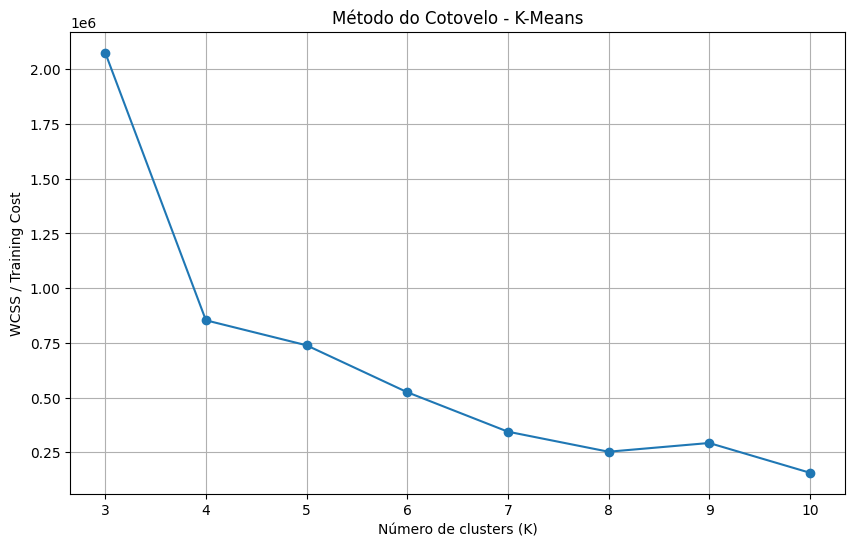

In [45]:
plotar_elbow(
    k_values,
    costs
)

### Best Kmeans

In [46]:
best_k = 8

df_clustered_financeiro, kmeans_model = treinar_kmeans(
    df_kmeans,
    k=best_k
)

In [47]:
df_clustered_financeiro = adicionar_pc1_pc2(
    df_clustered_financeiro
)

df_clustered_financeiro.select(
    "msno",
    "safra",
    "PC1",
    "PC2",
    "cluster"
)

DataFrame[msno: string, safra: string, PC1: double, PC2: double, cluster: int]

### Profiling

In [48]:
perfil_clusters = gerar_perfil_clusters(
    df_clustered_financeiro,
    dfs_train_dummy,
    features_cluster_financeiro+["actual_amount_paid"],
    feature_financeira="actual_amount_paid"
)

perfil_clusters.show(
    truncate=False
)

+-------+--------+------+--------------------+------------------+--------------------+-------------------+----------------------+--------------------+--------------------------+--------------------+------------------+-----------+--------------+
|cluster|clientes|churns|churn_rate          |ticket_medio      |qtd_transacoes      |delta_receita      |var_receita           |mudanca_preco       |intervalo_transacoes_meses|taxa_auto_renew_hist|actual_amount_paid|valor_total|valor_em_risco|
+-------+--------+------+--------------------+------------------+--------------------+-------------------+----------------------+--------------------+--------------------------+--------------------+------------------+-----------+--------------+
|0      |199016  |60000 |0.3014832978253005  |0.0               |0.006537162841178599|-0.9560839329501145|-0.006537162841178599 |-0.4372462515576637 |1.0                       |1.0                 |0.0               |0.0        |0.0           |
|1      |2734    |4 

### Churn by Cluster

In [49]:
perfil_churn = gerar_churn_por_cluster(
    df_clustered_financeiro,
    dfs_train_dummy
)

perfil_churn.show()

+-------+--------+------+--------------------+
|cluster|clientes|churns|          churn_rate|
+-------+--------+------+--------------------+
|      0|  199016| 60000|  0.3014832978253005|
|      1|    2734|     4|0.001463057790782736|
|      2|  105463| 22750| 0.21571546419123294|
|      3|     857|   285| 0.33255542590431736|
|      4|   10368|  2592|                0.25|
|      5|  641120| 51366| 0.08011916645869728|
|      6|     403|     0|                 0.0|
|      7|    2112|   522|  0.2471590909090909|
+-------+--------+------+--------------------+



### Plots

In [50]:
df_visualizacao = (
    df_pca_result
    .select(
        "msno",
        "safra",
        "PC1",
        "PC2"
    )
    .join(
        df_clustered_financeiro.select(
            "msno",
            "safra",
            "cluster"
        ),
        ["msno", "safra"],
        "inner"
    )
)

df_visualizacao.show(5)

+--------------------+------+--------------------+-------------------+-------+
|                msno| safra|                 PC1|                PC2|cluster|
+--------------------+------+--------------------+-------------------+-------+
|++JGYktWmyC4C/EUf...|201605|0.030758959216866978| 0.1123462721446788|      5|
|++WzwUilDTwylIR3E...|201607|   1.093821565996305|-1.2133718204785726|      2|
|++Xqq1LcF5dltTfVk...|201601|-0.05879704861144009|-2.0523097099535215|      2|
|++gzbSoJZRJod/mZc...|201607| -0.4476700918372785| -3.038250380876451|      2|
|++oXIXmgqlMjdoyLn...|201602|0.030758959216866978| 0.1123462721446788|      5|
+--------------------+------+--------------------+-------------------+-------+
only showing top 5 rows


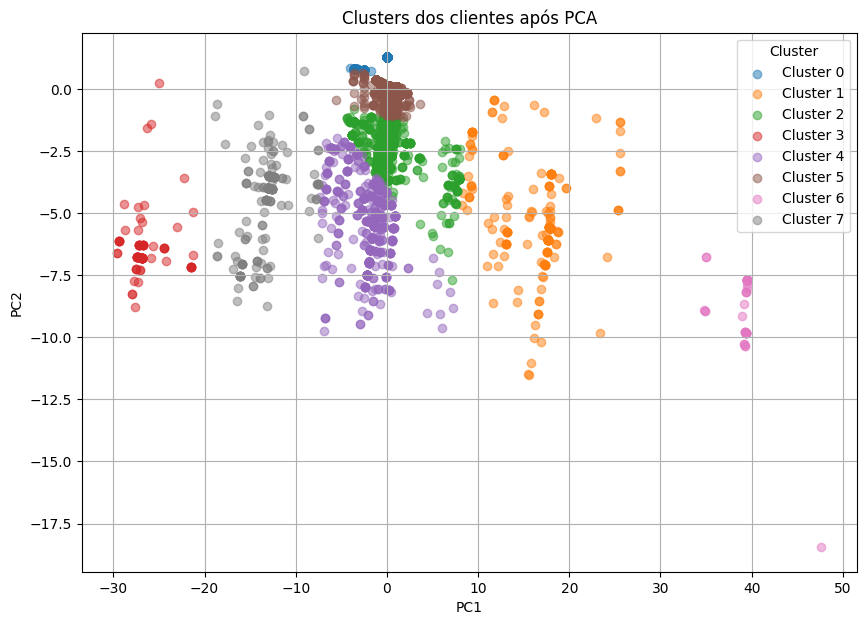

In [51]:
plotar_clusters(
    df_visualizacao,
    sample_fraction=0.1
)

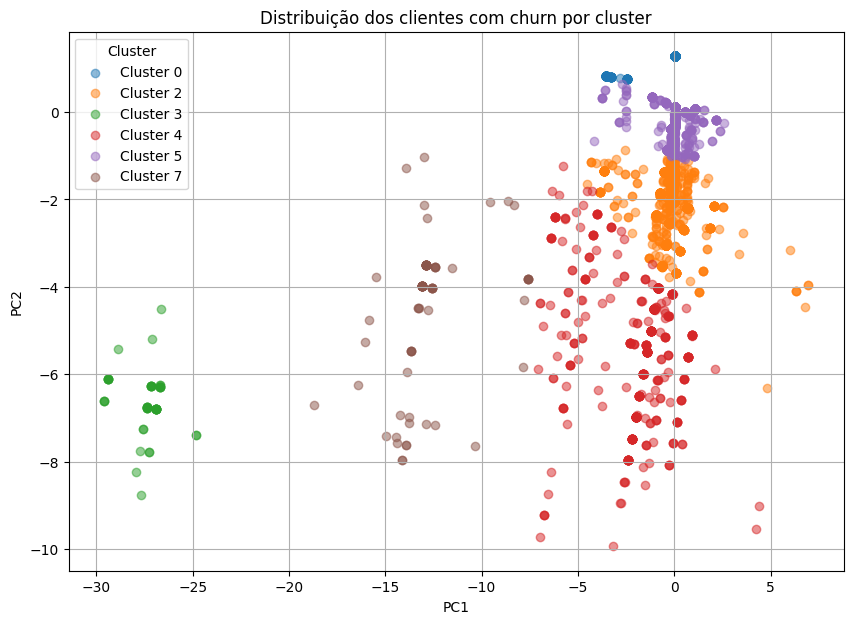

In [52]:
df_clustered_churn = adicionar_churn(
    df_clustered_financeiro,
    dfs_train_dummy
)

plotar_churn_por_cluster(
    df_clustered_churn,
    sample_fraction=0.2
)

In [53]:
df_centroides = (
    df_visualizacao
    .groupBy("cluster")
    .agg(
        F.avg("PC1").alias("PC1"),
        F.avg("PC2").alias("PC2"),
        F.count("*").alias("clientes")
    )
    .orderBy("cluster")
)

df_centroides.show()

+-------+--------------------+-------------------+--------+
|cluster|                 PC1|                PC2|clientes|
+-------+--------------------+-------------------+--------+
|      0| 0.03891647359417196| 1.2770995712040585|  199016|
|      1|  16.409640305126242| -5.279353287330324|    2734|
|      2|-0.17708823328451082| -2.159951886202856|  105463|
|      3| -26.677616809450985| -6.396100827027662|     857|
|      4| -1.6409211970610476|-4.9745656271339005|   10368|
|      5| 0.02779936630103673|0.09061894389581557|  641120|
|      6|   39.21440205313762| -9.371853504564575|     403|
|      7| -13.107502997026668|  -4.35487505584334|    2112|
+-------+--------------------+-------------------+--------+



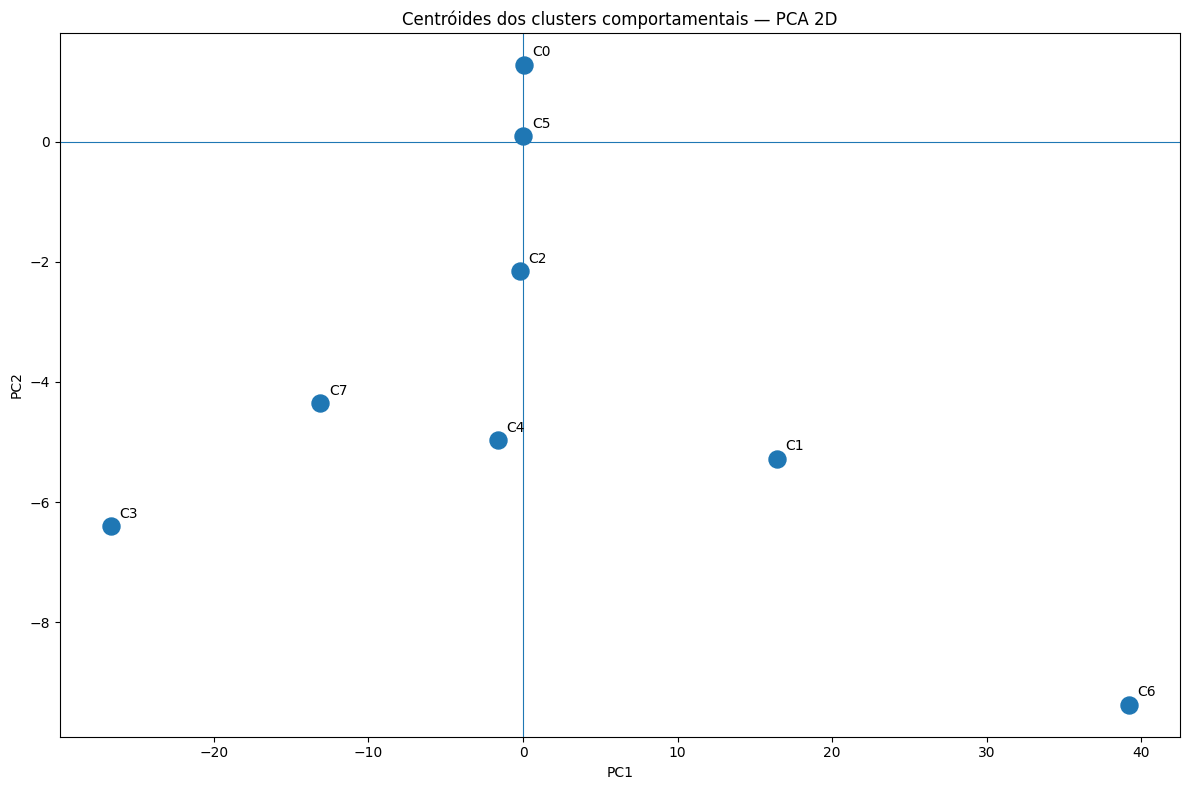

In [54]:
plotar_centroides(df_centroides)

In [55]:
pdf_perfil = perfil_clusters.toPandas()
pdf_perfil

,cluster,clientes,churns,churn_rate,ticket_medio,qtd_transacoes,delta_receita,var_receita,mudanca_preco,intervalo_transacoes_meses,taxa_auto_renew_hist,actual_amount_paid,valor_total,valor_em_risco
0,0,199016,60000,0.30,0.00,0.01,-0.96,-0.01,-0.44,1.00,1.00,0.00,0.00,0.00
1,1,2734,4,0.00,945.29,1.00,755.75,4.05,754.66,2.34,0.19,945.29,2584425.00,1359.00
2,2,105463,22750,0.22,154.89,1.00,3.02,0.00,2.78,1.93,0.16,154.89,16334980.00,3303286.00
3,3,857,285,0.33,170.32,1.00,-1603.12,-0.90,-1598.25,13.43,0.05,170.32,145968.00,38261.00
4,4,10368,2592,0.25,420.72,1.00,-17.57,-0.09,-10.92,7.50,0.10,420.72,4361980.00,286975.00
5,5,641120,51366,0.08,134.98,1.00,0.38,-0.00,-0.09,1.01,0.99,134.98,86541053.00,6494600.00
6,6,403,0,0.00,1769.91,1.00,1622.10,11.07,1622.47,1.60,0.37,1769.91,713274.00,0.00
7,7,2112,522,0.25,224.13,1.00,-782.80,-0.80,-692.12,7.93,0.06,224.13,473364.00,69448.00


### Matriz

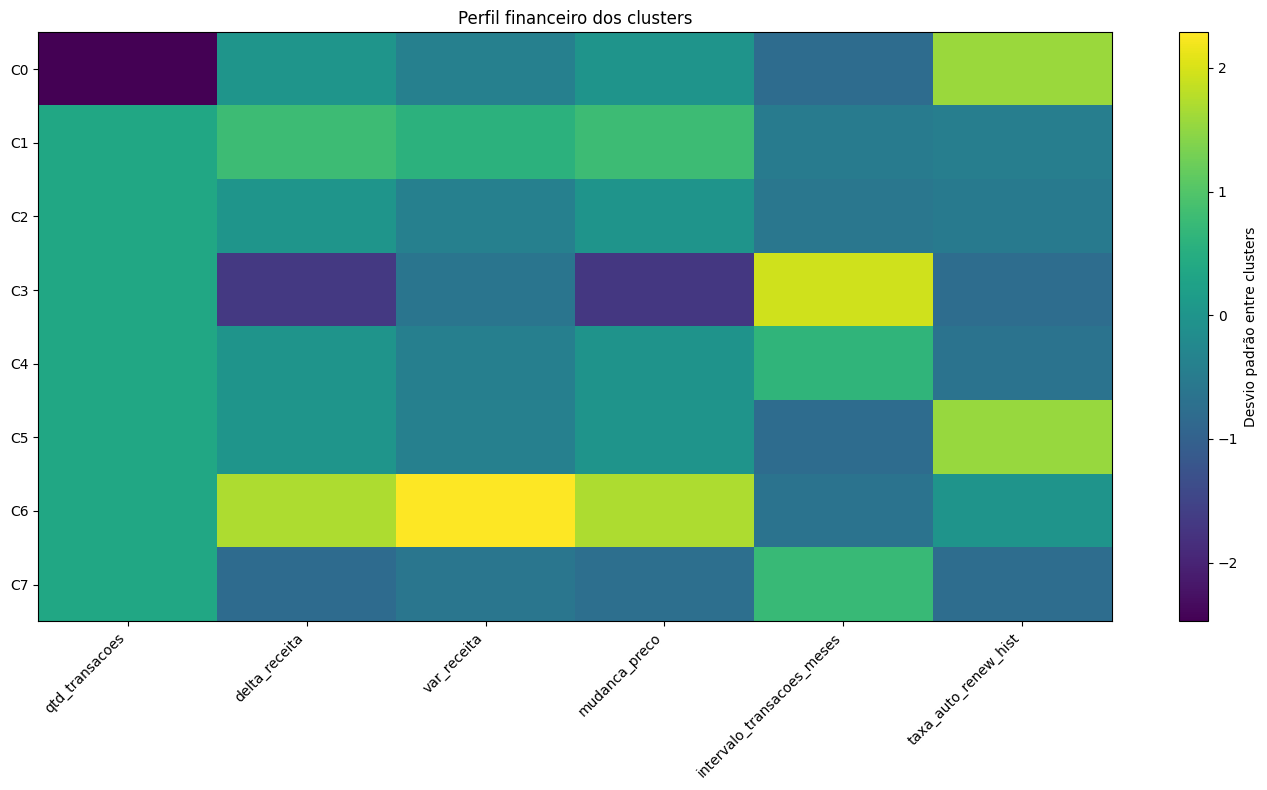

In [56]:
matriz = (
    pdf_perfil
    .set_index("cluster")[features_cluster_financeiro]
)

# Padronização por feature entre os clusters
matriz_z = (
    matriz - matriz.mean()
) / matriz.std()

plt.figure(figsize=(14, 8))

plt.imshow(
    matriz_z,
    aspect="auto"
)

plt.xticks(
    range(len(features_cluster_financeiro)),
    features_cluster_financeiro,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(matriz_z.index)),
    [f"C{i}" for i in matriz_z.index]
)

plt.colorbar(label="Desvio padrão entre clusters")

plt.title("Perfil financeiro dos clusters")

plt.tight_layout()
plt.show()

## Dados de Teste

In [57]:
# ==========================================
# TEST — CLUSTERIZAÇÃO COM MODELOS DO TRAIN
# ==========================================

# 1. Preparar features
df_test_assembled = assembler.transform(
    dfs_test_dummy
)

# 2. Aplicar scaler treinado no TRAIN
df_test_scaled = scaler_model.transform(
    df_test_assembled
)

# 3. Aplicar PCA treinado no TRAIN
df_test_pca = pca_model.transform(
    df_test_scaled
)

# 4. Criar PC1 e PC2 para visualização
df_test_pca = criar_componentes_pca(
    df_test_pca,
    n_components=2
)

# 5. Preparar entrada do KMeans
df_test_kmeans = preparar_kmeans(
    df_test_pca
)

# 6. Aplicar KMeans treinado no TRAIN
df_test_clustered = kmeans_model.transform(
    df_test_kmeans
)

# ==========================================
# PERFIL Financeiro
# ==========================================

perfil_comportamento_test = gerar_perfil_clusters(
    df_test_clustered,
    dfs_test_dummy,
    features_cluster_financeiro+["actual_amount_paid"],
    feature_financeira="actual_amount_paid"
)


perfil_comportamento_test.show(
    truncate=False
)

# ==========================================
# CHURN POR CLUSTER
# ==========================================

churn_comportamento_test = gerar_churn_por_cluster(
    df_test_clustered,
    dfs_test_dummy
)

churn_comportamento_test.show(
    truncate=False
)

+-------+--------+------+-------------------+------------------+--------------------+-------------------+---------------------+--------------------+--------------------------+--------------------+------------------+-----------+--------------+
|cluster|clientes|churns|churn_rate         |ticket_medio      |qtd_transacoes      |delta_receita      |var_receita          |mudanca_preco       |intervalo_transacoes_meses|taxa_auto_renew_hist|actual_amount_paid|valor_total|valor_em_risco|
+-------+--------+------+-------------------+------------------+--------------------+-------------------+---------------------+--------------------+--------------------------+--------------------+------------------+-----------+--------------+
|0      |129282  |43016 |0.332730001082904  |0.0               |0.004053155118268591|-0.5979177302331338|-0.004053155118268591|-0.03664083167030213|1.0                       |1.0                 |0.0               |0.0        |0.0           |
|1      |1879    |0     |0.0

## Validation

In [58]:
# ==========================================
# TEST — CLUSTERIZAÇÃO COM MODELOS DO TRAIN
# ==========================================

# 1. Preparar features
df_validation_assembled = assembler.transform(
    dfs_validacao_dummy
)

# 2. Aplicar scaler treinado no TRAIN
df_validation_scaled = scaler_model.transform(
    df_validation_assembled
)

# 3. Aplicar PCA treinado no TRAIN
df_validation_pca = pca_model.transform(
    df_validation_scaled
)

# 4. Criar PC1 e PC2 para visualização
df_validation_pca = criar_componentes_pca(
    df_validation_pca,
    n_components=2
)

# 5. Preparar entrada do KMeans
df_validation_kmeans = preparar_kmeans(
    df_validation_pca
)

# 6. Aplicar KMeans treinado no TRAIN
df_validation_clustered_financeiro = kmeans_model.transform(
    df_validation_kmeans
)

# ==========================================
# PERFIL Financeiro
# ==========================================

perfil_comportamento_validation = gerar_perfil_clusters(
    df_validation_clustered_financeiro,
    dfs_validacao_dummy,
    features_cluster_financeiro+["actual_amount_paid"],
    feature_financeira="actual_amount_paid"
)

perfil_comportamento_validation.show(
    truncate=False
)

# ==========================================
# CHURN POR CLUSTER
# ==========================================

churn_comportamento_validation = gerar_churn_por_cluster(
    df_validation_clustered_financeiro,
   dfs_validacao_dummy
)

churn_comportamento_validation.show(
    truncate=False
)

+-------+--------+------+-------------------+--------------------+--------------------+-------------------+---------------------+---------------------+--------------------------+--------------------+--------------------+-----------+--------------+
|cluster|clientes|churns|churn_rate         |ticket_medio        |qtd_transacoes      |delta_receita      |var_receita          |mudanca_preco        |intervalo_transacoes_meses|taxa_auto_renew_hist|actual_amount_paid  |valor_total|valor_em_risco|
+-------+--------+------+-------------------+--------------------+--------------------+-------------------+---------------------+---------------------+--------------------------+--------------------+--------------------+-----------+--------------+
|0      |124802  |46444 |0.3721414720917934 |7.932565183250269E-4|0.004294802967901155|-0.6319690389577091|-0.004293323011710251|-0.07322799314113555 |1.0                       |0.9999990651859212  |7.932565183250269E-4|99.0       |0.0           |
|1      

In [59]:
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", -1)

comparacao_comportamento = comparar_churn_clusters(
    perfil_churn,
    churn_comportamento_test,
    churn_comportamento_validation
)

comparacao_comportamento.show(
    truncate=False
)

+-------+--------------+------------+--------------------+-------------+-----------+-------------------+--------------+------------+-------------------+
|cluster|clientes_train|churns_train|churn_train         |clientes_test|churns_test|churn_test         |clientes_valid|churns_valid|churn_valid        |
+-------+--------------+------------+--------------------+-------------+-----------+-------------------+--------------+------------+-------------------+
|0      |199016        |60000       |0.3014832978253005  |129282       |43016      |0.332730001082904  |124802        |46444       |0.3721414720917934 |
|1      |2734          |4           |0.001463057790782736|1879         |0          |0.0                |1250          |0           |0.0                |
|2      |105463        |22750       |0.21571546419123294 |98991        |24644      |0.2489519249224677 |86657         |14036       |0.16197191225175114|
|3      |857           |285         |0.33255542590431736 |1297         |492       

# Oportunidades

In [60]:
df_oportunidades = (
    df_clustered_comportamento
    .select(
        "msno",
        "safra",
        F.col("cluster").alias("cluster_comportamento")
    )
    .join(
        df_clustered_financeiro.select(
            "msno",
            "safra",
            F.col("cluster").alias("cluster_financeiro")
        ),
        ["msno", "safra"],
        "inner"
    )
    .join(
        dfs_train_dummy.select(
            "msno",
            "safra",
            "churn_m3"
        ),
        ["msno", "safra"],
        "inner"
    )
)

In [61]:
churn_base = (
    dfs_validacao_dummy
    .agg(F.avg("churn_m3").alias("churn_base"))
    .first()["churn_base"]
)

print(f"Churn base treino: {churn_base:.4%}")

Churn base treino: 12.9752%


In [62]:
perfil_oportunidades = (
    df_oportunidades
    .groupBy(
        "cluster_comportamento",
        "cluster_financeiro"
    )
    .agg(
        F.count("*").alias("clientes"),
        F.sum("churn_m3").alias("churns"),
        F.avg("churn_m3").alias("churn_rate")
    )
    .withColumn(
        "churn_pct",
        F.round(F.col("churn_rate") * 100, 2)
    )
    .withColumn(
        "churn_base_pct",
        F.round(F.lit(churn_base) * 100, 2)
    )
    .withColumn(
        "delta_vs_base_pp",
        F.round(
            (F.col("churn_rate") - F.lit(churn_base)) * 100,
            2
        )
    )
    .withColumn(
        "razao_vs_base",
        F.round(
            F.col("churn_rate") / F.lit(churn_base),
            2
        )
    )
    .orderBy(
        F.desc("clientes")
    )
)

perfil_oportunidades.show(
    perfil_oportunidades.count(),
    truncate=False
)

+---------------------+------------------+--------+------+---------------------+---------+--------------+----------------+-------------+
|cluster_comportamento|cluster_financeiro|clientes|churns|churn_rate           |churn_pct|churn_base_pct|delta_vs_base_pp|razao_vs_base|
+---------------------+------------------+--------+------+---------------------+---------+--------------+----------------+-------------+
|0                    |5                 |214981  |15668 |0.07288085923872342  |7.29     |12.98         |-5.69           |0.56         |
|5                    |5                 |139320  |11159 |0.0800961814527706   |8.01     |12.98         |-4.97           |0.62         |
|6                    |5                 |111118  |7372  |0.0663438866790259   |6.63     |12.98         |-6.34           |0.51         |
|1                    |5                 |83716   |8928  |0.10664628028094988  |10.66    |12.98         |-2.31           |0.82         |
|0                    |0                 

# Join com RF

In [63]:
pred_validacao_grid = spark.read.parquet(
    "/content/drive/MyDrive/SANTANDER/pred_validation_grid.parquet"
)

df_rf_clusters = (
    pred_validacao_grid
    .select(
        "msno",
        "safra",
        "churn_m3",
        "prediction",
        "probability"
    )
    .join(
        df_validation_clustered_comportamento
        .select(
            "msno",
            "safra",
            F.col("cluster").alias("cluster_comportamento")
        ),
        ["msno", "safra"],
        "inner"
    )
    .join(
        df_validation_clustered_financeiro
        .select(
            "msno",
            "safra",
            F.col("cluster").alias("cluster_financeiro")
        ),
        ["msno", "safra"],
        "inner"
    )
)

df_rf_clusters = df_rf_clusters.withColumn(
    "prob_churn",
    vector_to_array(F.col("probability"))[1]
)

In [64]:
df_rf_clusters.limit(2).show()

+--------------------+------+--------+----------+--------------------+---------------------+------------------+------------------+
|                msno| safra|churn_m3|prediction|         probability|cluster_comportamento|cluster_financeiro|        prob_churn|
+--------------------+------+--------+----------+--------------------+---------------------+------------------+------------------+
|+++IZseRRiQS9aaSk...|201609|       0|       1.0|[0.22130037884889...|                    6|                 0|0.7786996211511095|
|+++l/EXNMLTijfLBa...|201609|       0|       1.0|[0.14410474436020...|                    6|                 5|0.8558952556397971|
+--------------------+------+--------+----------+--------------------+---------------------+------------------+------------------+



In [65]:
df_rf_clusters.select(
    "msno",
    "safra",
    "churn_m3",
    "prediction",
    "prob_churn",
    "cluster_comportamento",
    "cluster_financeiro"
)

analise_clusters_rf = (
    df_rf_clusters
    .groupBy(
        "cluster_comportamento",
        "cluster_financeiro"
    )
    .agg(
        F.count("*").alias("clientes"),

        F.sum("churn_m3").alias("churns"),

        F.avg("churn_m3").alias("churn_real"),

        F.avg("prob_churn").alias("prob_churn_media"),

        F.sum(
            F.when(F.col("prediction") == 1, 1).otherwise(0)
        ).alias("preditos_churn")
    )
    .withColumn(
        "churn_real_pct",
        F.round(F.col("churn_real") * 100, 2)
    )
    .withColumn(
        "prob_churn_media_pct",
        F.round(F.col("prob_churn_media") * 100, 2)
    )
    .withColumn(
        "pct_preditos_churn",
        F.round(
            F.col("preditos_churn") / F.col("clientes") * 100,
            2
        )
    )
    .orderBy(F.desc("clientes"))
)

analise_clusters_rf.show(
    analise_clusters_rf.count(),
    truncate=False
)

+---------------------+------------------+--------+------+--------------------+--------------------+--------------+--------------+--------------------+------------------+
|cluster_comportamento|cluster_financeiro|clientes|churns|churn_real          |prob_churn_media    |preditos_churn|churn_real_pct|prob_churn_media_pct|pct_preditos_churn|
+---------------------+------------------+--------+------+--------------------+--------------------+--------------+--------------+--------------------+------------------+
|0                    |5                 |251527  |14241 |0.05661817617989321 |0.32646038268014665 |41096         |5.66          |32.65               |16.34             |
|5                    |5                 |162521  |12342 |0.07594095532269676 |0.32849337024085634 |29063         |7.59          |32.85               |17.88             |
|6                    |5                 |124784  |4929  |0.039500256443133736|0.3364901178885222  |20905         |3.95          |33.65          

In [66]:
analise_clusters_rf = (
    analise_clusters_rf
    .withColumn(
        "erro_probabilidade_pp",
        F.round(
            (F.col("prob_churn_media") - F.col("churn_real")) * 100,
            2
        )
    )
)

analise_clusters_rf.show()

+---------------------+------------------+--------+------+--------------------+-------------------+--------------+--------------+--------------------+------------------+---------------------+
|cluster_comportamento|cluster_financeiro|clientes|churns|          churn_real|   prob_churn_media|preditos_churn|churn_real_pct|prob_churn_media_pct|pct_preditos_churn|erro_probabilidade_pp|
+---------------------+------------------+--------+------+--------------------+-------------------+--------------+--------------+--------------------+------------------+---------------------+
|                    0|                 5|  251527| 14241| 0.05661817617989321|0.32646038268014665|         41096|          5.66|               32.65|             16.34|                26.98|
|                    5|                 5|  162521| 12342| 0.07594095532269676|0.32849337024085634|         29063|          7.59|               32.85|             17.88|                25.26|
|                    6|                 

In [67]:
dfs_master = spark.read.parquet("/content/drive/MyDrive/SANTANDER/master.parquet")
df_rf_clusters = (
    df_rf_clusters
    .join(
        dfs_master
        .select(
            "msno",
            "safra",
            "ticket_medio"
        ),
        ["msno", "safra"],
        "left"
    )
)

In [68]:
df_rf_clusters = (
    df_rf_clusters
    .withColumn(
        "oportunidade",
        F.when(F.col("prediction") == 1, 1).otherwise(0)
    )
)

In [69]:
perfil_oportunidades = (
    df_rf_clusters
    .groupBy(
        "cluster_comportamento",
        "cluster_financeiro"
    )
    .agg(
        F.count("*").alias("clientes"),

        F.sum(
            F.when(F.col("churn_m3") == 1, 1).otherwise(0)
        ).alias("churns_reais"),

        F.sum(
            F.when(
                (F.col("prediction") == 1) &
                (F.col("churn_m3") == 1),
                1
            ).otherwise(0)
        ).alias("churns_identificados"),

        F.sum(
            F.when(F.col("prediction") == 1, 1).otherwise(0)
        ).alias("clientes_oportunidade"),

        F.avg("ticket_medio").alias("ticket_medio"),

        F.avg(
            F.when(F.col("churn_m3") == 1, F.col("ticket_medio"))
        ).alias("ticket_medio_churn")
    )
)

In [70]:
TICKET_REFERENCIA = 144.93843578321815

perfil_oportunidades = (
    perfil_oportunidades
    .withColumn(
        "gap_ticket",
        F.greatest(
            F.lit(TICKET_REFERENCIA) - F.col("ticket_medio"),
            F.lit(0)
        )
    )
    .withColumn(
        "potencial_mensal",
        F.col("clientes_oportunidade") * F.col("gap_ticket")
    )
    .withColumn(
        "taxa_identificacao_churn",
        F.when(
            F.col("churns_reais") > 0,
            F.col("churns_identificados") / F.col("churns_reais")
        )
    )
)

In [71]:
perfil_oportunidades.orderBy(
    F.desc("potencial_mensal")
).show(50, truncate=False)

+---------------------+------------------+--------+------------+--------------------+---------------------+------------------+------------------+------------------+------------------+------------------------+
|cluster_comportamento|cluster_financeiro|clientes|churns_reais|churns_identificados|clientes_oportunidade|ticket_medio      |ticket_medio_churn|gap_ticket        |potencial_mensal  |taxa_identificacao_churn|
+---------------------+------------------+--------+------------+--------------------+---------------------+------------------+------------------+------------------+------------------+------------------------+
|0                    |0                 |44911   |16699       |16699               |44896                |0.0               |0.0               |144.93843578321815|6507156.012923363 |1.0                     |
|6                    |0                 |29737   |10086       |10083               |29725                |0.9339622641509434|0.0               |144.0044735190672 |

In [72]:
tickets = (
    df_rf_clusters
    .groupBy("churn_m3")
    .agg(
        F.avg("ticket_medio").alias("ticket_medio")
    )
)

tickets.show()

+--------+------------------+
|churn_m3|      ticket_medio|
+--------+------------------+
|       1| 89.41964596489484|
|       0|138.45046838650177|
+--------+------------------+



In [73]:
ticket_nao_churn = (
    df_rf_clusters
    .filter(F.col("churn_m3") == 0)
    .agg(
        F.avg("ticket_medio").alias("ticket_referencia")
    )
    .first()["ticket_referencia"]
)

print(f"Ticket médio não churn: R$ {ticket_nao_churn:.2f}")

Ticket médio não churn: R$ 138.45


In [74]:
oportunidade_rf = (
    df_rf_clusters
    .filter(F.col("prediction") == 1)
    .agg(
        F.count("*").alias("clientes_identificados_rf"),

        F.sum(
            F.when(F.col("churn_m3") == 1, 1).otherwise(0)
        ).alias("churns_reais"),

        F.avg("ticket_medio").alias("ticket_medio_oportunidade")
    )
    .withColumn(
        "taxa_churn_oportunidade",
        F.col("churns_reais") / F.col("clientes_identificados_rf")
    )
    .withColumn(
        "gap_ticket",
        F.lit(ticket_nao_churn) - F.col("ticket_medio_oportunidade")
    )
    .withColumn(
        "potencial_mensal",
        F.col("clientes_identificados_rf") * F.col("gap_ticket")
    )
)

oportunidade_rf.show(truncate=False)

+-------------------------+------------+-------------------------+-----------------------+----------------+-----------------+
|clientes_identificados_rf|churns_reais|ticket_medio_oportunidade|taxa_churn_oportunidade|gap_ticket      |potencial_mensal |
+-------------------------+------------+-------------------------+-----------------------+----------------+-----------------+
|352969                   |112079      |131.2403947477733        |0.31753213455005963    |7.21007363872846|2544932.482188346|
+-------------------------+------------+-------------------------+-----------------------+----------------+-----------------+

